# TD(0) and n-Step TD Algorithms

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand Temporal Difference (TD) learning
- Implement TD(0) algorithm
- Implement n-step TD algorithms
- Compare TD with Monte Carlo methods
- Apply TD algorithms to RL environments

## 🔗 Prerequisites

- ✅ Understanding of value functions
- ✅ Monte Carlo methods knowledge
- ✅ Python knowledge (functions, loops, NumPy)
- ✅ Understanding of bootstrapping

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 2**:
- Running TD(0) and n-step TD algorithms in simple RL environments

---

## Introduction

**Temporal Difference (TD) learning** combines ideas from Monte Carlo (learning from experience) and Dynamic Programming (bootstrapping). TD methods update estimates based on other estimates, making them more sample-efficient than Monte Carlo.

## Lesson Brief

This lesson introduces **temporal-difference learning**, especially TD(0) and n-step ideas.

Students will see how an agent can learn before an episode finishes by bootstrapping from current estimates.

Why this matters: TD methods are central to modern RL because they mix observed rewards with learned predictions.

This lesson connects Monte Carlo intuition to scalable online learning.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **RTG Computational Cognition - "Reinforcement Learning Crash Course - n-step TD Learning"**:
[Watch on YouTube](https://www.youtube.com/watch?v=FQlnE44Lha0)

Why this pick:
- Clear English lecture style and focused explanation.
- Shows how n-step TD bridges one-step TD and Monte Carlo ideas.
- Useful when students need intuition for why bootstrapping depth matters.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Bootstrapping: learning from an estimate of future value instead of waiting for the full return.
- TD error: target minus current estimate.
- TD(0): one-step update using immediate reward plus one estimated future value.
- n-step return: several real rewards first, then bootstrap.

### Quick Check
- Why can bootstrapping speed learning?
- How does n-step sit between MC and TD(0)?
- What does a large TD error mean?
- Why is TD often more online than Monte Carlo?

### Common Mistakes
- Thinking bootstrapping is invalid.
- Seeing TD(0) and n-step as unrelated.
- Losing track of where reward stops and estimate begins.
- Forgetting that TD trades some variance reduction for bias and speed.


## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


## TD Learning in Plain Language

Temporal-difference learning keeps the Monte Carlo idea of learning from experience, but it stops waiting for the episode to finish.

### The core idea

Instead of saying:

`I will wait until I know the full return.`

TD says:

`I already know something useful now, so I can update earlier.`

That is where bootstrapping comes from.

### Monte Carlo vs TD

- **Monte Carlo**: wait for the full episode, then use the real return.
- **TD(0)**: use one real reward now, then rely on an estimate for the rest.

So TD is usually faster and more online, but it depends on current estimates that may still be imperfect.

### Where does n-step fit?

n-step TD is the middle ground:

- use several real rewards first
- then bootstrap from an estimate

That is why students should think of n-step as a bridge between Monte Carlo and TD(0), not as a completely separate family.

### Classroom intuition

Bootstrapping is not "guessing randomly."
It is reusing the best estimate the agent currently has so learning can begin earlier.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt
# Load a library so you can use its ready-made functions and types below.
from collections import defaultdict

# Show text or numbers in the cell output area under the code.
print("✅ Libraries imported!")
# Show text or numbers in the cell output area under the code.
print("\nTD(0) and n-Step TD Algorithms")
# Show text or numbers in the cell output area under the code.
print("=" * 60)


✅ Libraries imported!

TD(0) and n-Step TD Algorithms


## Part 1: Understanding TD Learning


### Step Guide

**What this cell does:** Computes **one single TD(0) update by hand** with tiny concrete numbers: the TD target, the TD error, and the corrected value.

**How to read it (weak Python OK):** Five named numbers go in (`v_s`, `reward`, `v_s_next`, `gamma`, `alpha`); three computed numbers come out. Check each printed line with mental arithmetic.

**What to expect in the output:** A short table of the ingredients and the updated value `V(s)`.

**If you feel lost:** Keep only one sentence: the update mixes *one real reward* with *an existing estimate* — that mix is bootstrapping.

In [2]:
# Part 1: Understanding TD Learning — one single TD(0) update computed by hand.
# Seeing the formula once with real numbers makes the training loops below much easier to read.

# Print the section banner so the output matches the notebook headers.
print("=" * 60)
print("Part 1: Understanding TD Learning")
print("=" * 60)

# The agent sits in state s with an existing estimate, then observes ONE step of experience.
v_s = 2.0        # current estimate of V(s) before the update
v_s_next = 3.0   # current estimate of V(s') for the state that followed
reward = 1.0     # the one real reward observed on the transition s -> s'
gamma = 0.9      # discount factor: how much future value still counts
alpha = 0.5      # learning rate: how big a correction step to take

# TD target = one real reward + discounted current estimate of the next state.
td_target = reward + gamma * v_s_next
# TD error = how "surprised" the old estimate was by that target.
td_error = td_target - v_s
# The update moves V(s) a fraction alpha of the way toward the target.
v_s_updated = v_s + alpha * td_error

# Print every ingredient so students can verify the arithmetic by hand.
print(f"\nCurrent estimate V(s)          : {v_s:.2f}")
print(f"Observed reward r              : {reward:.2f}")
print(f"Estimate of next state V(s')   : {v_s_next:.2f}")
print(f"TD target   r + gamma * V(s')  : {td_target:.2f}")
print(f"TD error    target - V(s)      : {td_error:.2f}")
print(f"Updated V(s) after one step    : {v_s_updated:.2f}")

# One-sentence takeaway tying the numbers back to the theory above.
print("\nKey idea: the update used ONE real reward plus an existing estimate --")
print("no waiting for the episode to finish. That is bootstrapping.")


Part 1: Understanding TD Learning

Current estimate V(s)          : 2.00
Observed reward r              : 1.00
Estimate of next state V(s')   : 3.00
TD target   r + gamma * V(s')  : 3.70
TD error    target - V(s)      : 1.70
Updated V(s) after one step    : 2.85

Key idea: the update used ONE real reward plus an existing estimate --
no waiting for the episode to finish. That is bootstrapping.


## Part 2: TD(0) Implementation


### Step Guide

**What this cell does:** Implements **TD(0) prediction** on a classic 5-state random walk whose exact true values are known (1/6 … 5/6), then compares the learned estimates with the truth.

**How to read it (weak Python OK):** `random_walk_episode` rolls one episode; `td0_random_walk` applies the Part 1 update after *every step* of every episode. The final table is the whole point.

**What to expect in the output:** A small state-by-state table of TD(0) estimate vs true value, plus one RMS-error number.

**If you feel lost:** Only compare the two number columns — TD(0) never sees the true values, yet it lands close to them.

In [3]:
# Part 2: TD(0) implementation — estimate state values on a 5-state random walk.
# This tiny chain has KNOWN true values, so we can measure how close TD(0) gets.

# Print the section banner so the output matches the notebook headers.
print("\n" + "=" * 60)
print("Part 2: TD(0) Implementation")
print("=" * 60)

# Fixed seed so the printed numbers are reproducible in class.
rng = np.random.default_rng(42)

# Random-walk chain: states 0..6, terminals at 0 and 6, start in the middle (state 3).
# The only reward is +1 for finishing at the RIGHT terminal (state 6).
N_CHAIN = 7
TRUE_VALUES = np.arange(1, 6) / 6.0   # exact answer for states 1..5: 1/6 .. 5/6


def random_walk_episode(rng):
    """Roll one episode; return the visited states and the single final reward."""
    # Start in the middle of the chain.
    state = 3
    states = [state]
    # Step left or right with equal probability until a terminal is reached.
    while state not in (0, 6):
        state += rng.choice([-1, 1])
        states.append(state)
    # +1 only if the walk ended on the right side.
    reward = 1.0 if state == 6 else 0.0
    return states, reward


def td0_random_walk(episodes=200, alpha=0.1, rng=None):
    """TD(0) prediction with gamma = 1: apply the Part 1 update after every step."""
    # Start every non-terminal at a neutral 0.5; terminals hold value 0.
    values = np.full(N_CHAIN, 0.5)
    values[0] = values[6] = 0.0
    # Learn online: one small update per observed transition.
    for _ in range(episodes):
        states, final_reward = random_walk_episode(rng)
        for t in range(len(states) - 1):
            s, s_next = states[t], states[t + 1]
            # The reward is 0 on every step except entering the right terminal.
            r = final_reward if s_next == 6 else 0.0
            # Same update as Part 1: target = r + V(s'), error, small correction.
            values[s] += alpha * (r + values[s_next] - values[s])
    return values


# Run TD(0) and compare the learned estimates with the exact chain values.
td0_chain_values = td0_random_walk(episodes=200, alpha=0.1, rng=rng)

# Print the comparison table students should study line by line.
print("\nState | TD(0) estimate | true value")
for s in range(1, 6):
    print(f"  {s}   |     {td0_chain_values[s]:.3f}      |   {TRUE_VALUES[s - 1]:.3f}")

# One summary number: root-mean-square error across the five learnable states.
rmse_td0 = np.sqrt(np.mean((td0_chain_values[1:6] - TRUE_VALUES) ** 2))
print(f"\nRMS error after 200 episodes: {rmse_td0:.3f}")
print("TD(0) moved toward the true values without ever being shown them.")



Part 2: TD(0) Implementation

State | TD(0) estimate | true value
  1   |     0.091      |   0.167
  2   |     0.244      |   0.333
  3   |     0.483      |   0.500
  4   |     0.711      |   0.667
  5   |     0.820      |   0.833

RMS error after 200 episodes: 0.057
TD(0) moved toward the true values without ever being shown them.


## Part 3: n-Step TD Implementation


### Step Guide

**What this cell does:** Implements **n-step TD** on the same random walk and compares `n = 1, 3, 5` by their RMS error against the known true values.

**How to read it (weak Python OK):** The only change from Part 2 is the target: sum up to `n` real rewards first, *then* bootstrap from `V`. The small printed table is the result.

**What to expect in the output:** One RMS-error row per `n`, plus a computed line naming which `n` did best *on this run*.

**If you feel lost:** Remember the axis: `n = 1` is TD(0); very large `n` behaves like Monte Carlo. The printed line names the winner for this run only — it is not a law.

In [4]:
# Part 3: n-step TD — same random walk, but each update looks n real steps ahead.
# Comparing n = 1, 3, 5 makes the bridge between TD(0) and Monte Carlo concrete.

# Print the section banner so the output matches the notebook headers.
print("\n" + "=" * 60)
print("Part 3: n-Step TD Implementation")
print("=" * 60)


def n_step_td_random_walk(n, episodes=200, alpha=0.1, seed=7):
    """n-step TD prediction (gamma = 1) on the random-walk chain from Part 2."""
    # Separate generator so every n uses the SAME episode stream (fair comparison).
    rng_local = np.random.default_rng(seed)
    # Neutral start for non-terminals; terminals hold value 0.
    values = np.full(N_CHAIN, 0.5)
    values[0] = values[6] = 0.0
    for _ in range(episodes):
        states, final_reward = random_walk_episode(rng_local)
        T = len(states) - 1   # number of transitions in this episode
        # Reward is 0 everywhere except the step that enters the right terminal.
        rewards = [final_reward if states[t + 1] == 6 else 0.0 for t in range(T)]
        for t in range(T):
            # n-step return: up to n real rewards, then bootstrap from V.
            upper = min(t + n, T)
            # Terminal states keep value 0, so adding values[states[upper]] is always safe.
            g = sum(rewards[t:upper]) + values[states[upper]]
            # Same small-correction update as before, with the longer target.
            values[states[t]] += alpha * (g - values[states[t]])
    return values


# Compare three lookahead depths on identical episode streams.
print("\n  n  | RMS error vs true values (200 episodes, alpha=0.1)")
results_n = {}
for n in (1, 3, 5):
    v = n_step_td_random_walk(n)
    rmse = np.sqrt(np.mean((v[1:6] - TRUE_VALUES) ** 2))
    results_n[n] = rmse
    print(f"  {n}  |  {rmse:.3f}")

# Compute (not assume) which n did best on this particular run.
best_n = min(results_n, key=results_n.get)
print(f"\nOn this run, n={best_n} gave the lowest error.")
print("Larger n uses more real rewards per update (more like Monte Carlo);")
print("smaller n bootstraps sooner (more like TD(0)). Neither extreme always wins.")



Part 3: n-Step TD Implementation

  n  | RMS error vs true values (200 episodes, alpha=0.1)
  1  |  0.038
  3  |  0.073
  5  |  0.092

On this run, n=1 gave the lowest error.
Larger n uses more real rewards per update (more like Monte Carlo);
smaller n bootstraps sooner (more like TD(0)). Neither extreme always wins.


## 🌍 Worked Example — Inventory Value Prediction with TD Learning

**Industry context:**
- Retail systems estimate future stock health before a full demand cycle finishes
- Operations teams update forecasts as each day of sales arrives
- RL prediction methods help connect immediate outcomes to future value estimates

We model a simple **inventory process** and compare **TD(0)** with a short **3-step TD** return, so students can see how both methods learn from partial experience rather than waiting for the whole episode.

### Step Guide

**What this cell does:** Run a worked scenario step by step; compare each print to the markdown theory.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


Estimated value of stock level 0 with TD(0): 26.7
Estimated value of stock level 0 with 3-step TD: 18.94
Interpretation: both methods learn online, but 3-step TD uses a slightly longer return before bootstrapping.


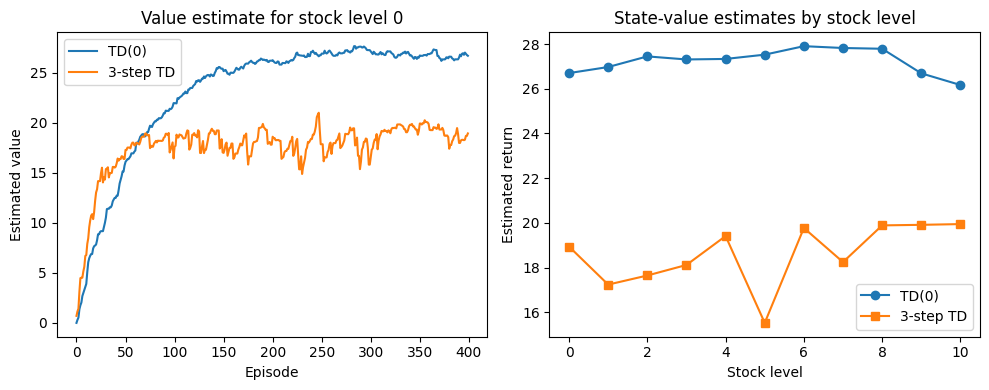

In [5]:
# Worked example: compare one-step TD with a short n-step return on the same inventory process.
# The aim is prediction, not control, so we estimate the value of stock levels under a fixed policy.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)

# Save a value in a name so the next lines can read it.
MAX_STOCK = 10
# Set discount factor gamma used inside r + gamma * V(s') targets.
GAMMA = 0.95

# Function `fixed_policy` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: stock_level.
def fixed_policy(stock_level):
    # Send a value back to whoever called this function.
    return 1 if stock_level <= 2 else 0

# Function `step` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: state, action.
def step(state, action):
    # Save a value in a name so the next lines can read it.
    new_state = min(state + action * 5, MAX_STOCK)
    # Another assignment—same idea: store a value for the lines below.
    demand = np.random.randint(0, 4)
    # Another assignment—same idea: store a value for the lines below.
    sold = min(new_state, demand)
    # Unpack the one-step model output from transition(state, action).
    reward = sold - (2 if demand > new_state else 0) - (0.5 * action)
    # Save a value in a name so the next lines can read it.
    new_state = max(new_state - demand, 0)
    # Send a value back to whoever called this function.
    return new_state, reward

# Function `generate_episode` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: length.
def generate_episode(length=30):
    # Create or choose a variable used in the Bellman warm-up demo.
    state = np.random.randint(0, MAX_STOCK + 1)
    # Save a value in a name so the next lines can read it.
    states = [state]
    # Unpack the one-step model output from transition(state, action).
    rewards = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(length):
        # Save a value in a name so the next lines can read it.
        action = fixed_policy(state)
        # Unpack the one-step model output from transition(state, action).
        next_state, reward = step(state, action)
        # Add one new item to the end of a list (the list grows in place).
        rewards.append(reward)
        # Add one new item to the end of a list (the list grows in place).
        states.append(next_state)
        # Create or choose a variable used in the Bellman warm-up demo.
        state = next_state
    # Send a value back to whoever called this function.
    return states, rewards

# Function `td0_prediction` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: alpha, episodes.
def td0_prediction(alpha=0.1, episodes=400):
    # Create or choose a variable used in the Bellman warm-up demo.
    values = np.zeros(MAX_STOCK + 1)
    # Save a value in a name so the next lines can read it.
    history = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(episodes):
        # Save a value in a name so the next lines can read it.
        states, rewards = generate_episode()
        # Start a loop: repeat the indented block once per item in the sequence.
        for t, reward in enumerate(rewards):
            # Save a value in a name so the next lines can read it.
            s = states[t]
            # Another assignment—same idea: store a value for the lines below.
            s_next = states[t + 1]
            # Another assignment—same idea: store a value for the lines below.
            td_target = reward + GAMMA * values[s_next]
            # Create or choose a variable used in the Bellman warm-up demo.
            values[s] += alpha * (td_target - values[s])
        # Add one new item to the end of a list (the list grows in place).
        history.append(values[0])
    # Send a value back to whoever called this function.
    return values, history

# Function `n_step_prediction` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: n, alpha, episodes.
def n_step_prediction(n=3, alpha=0.1, episodes=400):
    # Create or choose a variable used in the Bellman warm-up demo.
    values = np.zeros(MAX_STOCK + 1)
    # Save a value in a name so the next lines can read it.
    history = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(episodes):
        # Save a value in a name so the next lines can read it.
        states, rewards = generate_episode()
        # Another assignment—same idea: store a value for the lines below.
        T = len(rewards)
        # Start a loop: repeat the indented block once per item in the sequence.
        for t in range(T):
            # Save a value in a name so the next lines can read it.
            g = 0.0
            # Another assignment—same idea: store a value for the lines below.
            upper = min(t + n, T)
            # Start a loop: repeat the indented block once per item in the sequence.
            for k in range(t, upper):
                # Save a value in a name so the next lines can read it.
                g += (GAMMA ** (k - t)) * rewards[k]
            # If the condition is True, run the indented block under this line.
            if t + n < len(states):
                # Save a value in a name so the next lines can read it.
                g += (GAMMA ** n) * values[states[t + n]]
            # Create or choose a variable used in the Bellman warm-up demo.
            values[states[t]] += alpha * (g - values[states[t]])
        # Add one new item to the end of a list (the list grows in place).
        history.append(values[0])
    # Send a value back to whoever called this function.
    return values, history

# Save a value in a name so the next lines can read it.
td0_values, td0_history = td0_prediction()
# Another assignment—same idea: store a value for the lines below.
three_step_values, three_step_history = n_step_prediction(n=3)

# Show text or numbers in the cell output area under the code.
print("Estimated value of stock level 0 with TD(0):", round(td0_values[0], 2))
# Show text or numbers in the cell output area under the code.
print("Estimated value of stock level 0 with 3-step TD:", round(three_step_values[0], 2))
# Show text or numbers in the cell output area under the code.
print("Interpretation: both methods learn online, but 3-step TD uses a slightly longer return before bootstrapping.")

# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.figure(figsize=(10, 4))
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1, 2, 1)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(td0_history, label="TD(0)")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(three_step_history, label="3-step TD")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Value estimate for stock level 0")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xlabel("Episode")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.ylabel("Estimated value")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.legend()

# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1, 2, 2)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(td0_values, marker="o", label="TD(0)")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(three_step_values, marker="s", label="3-step TD")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("State-value estimates by stock level")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xlabel("Stock level")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.ylabel("Estimated return")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.show()


## Summary

### Key Concepts:
1. **TD Learning**: Combines Monte Carlo (experience) and DP (bootstrapping)
2. **TD(0)**: 1-step TD, updates: V(S_t) ← V(S_t) + α[R + γV(S_{t+1}) - V(S_t)]
3. **n-Step TD**: Uses n-step returns, balances bias and variance
4. **Bootstrapping**: Update using other estimates (faster but biased)

### Comparison:
- **Monte Carlo**: High variance, no bias, requires episodes
- **TD(0)**: Low variance, some bias, online (incremental)
- **n-Step TD**: Trade-off between MC and TD(0)

### Advantages:
- Online learning (no need to wait for episode end)
- Lower variance than Monte Carlo
- More sample-efficient
- Works for continuing tasks

### Applications:
- Value function estimation
- Policy evaluation
- Online learning scenarios

### Next Steps:
- SARSA and Q-learning (TD control)
- Eligibility traces (TD(λ))
- Compare with Monte Carlo and DP

**Reference:** Course 09, Unit 2: "Prediction and Control without a Model" - TD algorithms practical content

In [6]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Sutton, R. S. (1988). *Learning to Predict by the Methods of Temporal Differences*. Machine Learning, 3. <https://link.springer.com/article/10.1007/BF00115009>
2. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 6-7, TD Learning and n-step Bootstrapping.
3. Fedus, W., Ramachandran, P., Agarwal, R. et al. (2020). *Revisiting Fundamentals of Experience Replay*. ICML. <https://arxiv.org/abs/2007.06700>
"""))

## 📚 References

1. Sutton, R. S. (1988). *Learning to Predict by the Methods of Temporal Differences*. Machine Learning, 3. <https://link.springer.com/article/10.1007/BF00115009>
2. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 6-7, TD Learning and n-step Bootstrapping.
3. Fedus, W., Ramachandran, P., Agarwal, R. et al. (2020). *Revisiting Fundamentals of Experience Replay*. ICML. <https://arxiv.org/abs/2007.06700>


### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


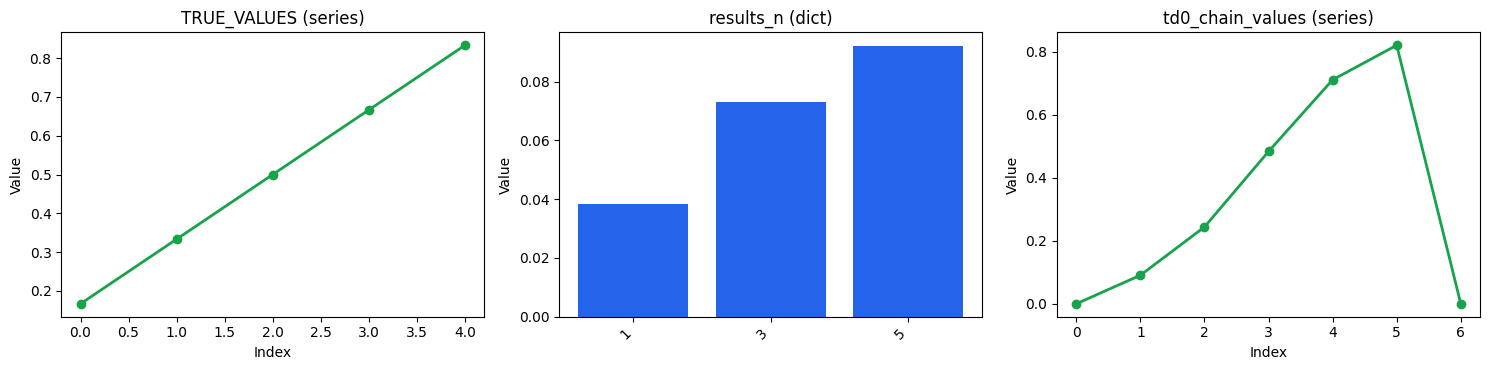

In [7]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** TD methods update before the episode ends by bootstrapping from current estimates, which makes learning faster and more incremental.

**If students remember one idea:** Temporal-difference learning is the bridge between Monte Carlo intuition and dynamic programming structure.

**Quick check before moving on:**
- Can you explain what bootstrapping means in TD learning?
- Can you describe how TD(0) and n-step TD trade off speed and target quality?

**Bridge to the next step:** With these update styles in mind, students can compare solution methods more clearly in the next lesson.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=3 | term=True | trunc=False


objc[14276]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x112358138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1128989c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[14276]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x112358188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x112898a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[14276]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x112357c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x112898a68). T

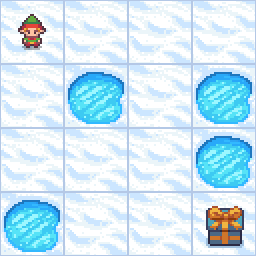

In [8]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
